In [1]:
pip install pandas matplotlib seaborn openpyxl scipy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape: (41188, 21)

Column names:
 ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Data types:
 age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

First 5 rows:
    age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      

In [3]:
# missing values 

In [4]:
print("\nMissing values:\n", df.isnull().sum())

# This dataset uses 'unknown' as a string placeholder
# Count them per column
for col in df.columns:
    unknowns = (df[col] == 'unknown').sum()
    if unknowns > 0:
        print(f"{col}: {unknowns} unknowns ({round(unknowns/len(df)*100,1)}%)")


Missing values:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
job: 330 unknowns (0.8%)
marital: 80 unknowns (0.2%)
education: 1731 unknowns (4.2%)
default: 8597 unknowns (20.9%)
housing: 990 unknowns (2.4%)
loan: 990 unknowns (2.4%)


In [7]:
# Replace 'unknown' with NaN 
df.replace('unknown', pd.NA, inplace=True)


# Create a binary target column (easier to calculate with numbers)
df['subscribed'] = (df['y'] == 'yes').astype(int)

df.to_csv('bank_customers_clean.csv', index=False)
print("\nClean file saved. Shape:", df.shape)
print("Subscription rate:", round(df['subscribed'].mean() * 100, 2), "%")


Clean file saved. Shape: (41188, 22)
Subscription rate: 11.27 %


In [9]:
#Calculate core financial/operational KPIs from the cleaned data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank_customers_clean.csv')

# ── KPI 1: Overall conversion rate ──────────────────────────────────────────
total = len(df)
converted = df['subscribed'].sum()
conversion_rate = round(converted / total * 100, 2)
print(f"Total customers contacted: {total:,}")
print(f"Total subscribed: {converted:,}")
print(f"Overall conversion rate: {conversion_rate}%")

Total customers contacted: 41,188
Total subscribed: 4,640
Overall conversion rate: 11.27%



Conversion rate by job:
               job  total  subscribed  conversion_rate
8         student    875         275            31.43
5         retired   1720         434            25.23
10     unemployed   1014         144            14.20
0          admin.  10422        1352            12.97
4      management   2924         328            11.22
9      technician   6743         730            10.83
6   self-employed   1421         149            10.49
3       housemaid   1060         106            10.00
2    entrepreneur   1456         124             8.52
7        services   3969         323             8.14
1     blue-collar   9254         638             6.89


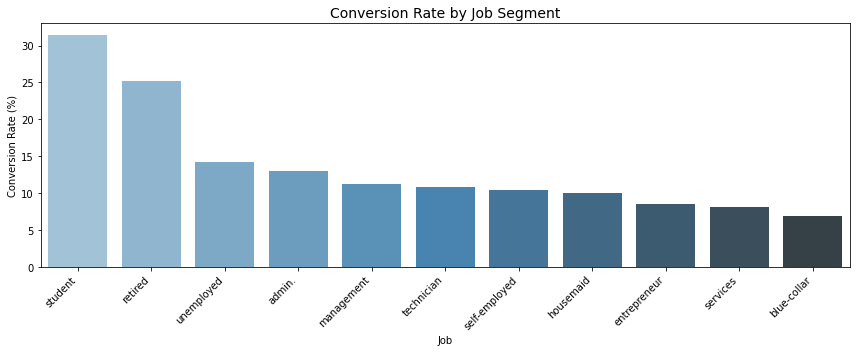

Chart saved.


In [11]:
# ── KPI 2: Conversion rate by job segment ────
job_kpi = df.groupby('job').agg(
    total=('subscribed', 'count'),
    subscribed=('subscribed', 'sum')
).reset_index()

job_kpi['conversion_rate'] = round(job_kpi['subscribed'] / job_kpi['total'] * 100, 2)
job_kpi = job_kpi.sort_values('conversion_rate', ascending=False)

print("\nConversion rate by job:\n", job_kpi)

# Chart 1: Bar chart of conversion rates by job
plt.figure(figsize=(12, 5))
sns.barplot(data=job_kpi, x='job', y='conversion_rate', palette='Blues_d')
plt.title('Conversion Rate by Job Segment', fontsize=14)
plt.xlabel('Job')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/chart_01_conversion_by_job.png', dpi=150)
plt.show()
print("Chart saved.")


Campaign efficiency:
     campaign  contacts  conversions  conversion_rate
0          1     17642         2300            13.04
1          2     10570         1211            11.46
2          3      5341          574            10.75
3          4      2651          249             9.39
4          5      1599          120             7.50
5          6       979           75             7.66
6          7       629           38             6.04
7          8       400           17             4.25
8          9       283           17             6.01
9         10       225           12             5.33
10        11       177           12             6.78
11        12       125            3             2.40
12        13        92            4             4.35
13        14        69            1             1.45
14        15        51            2             3.92


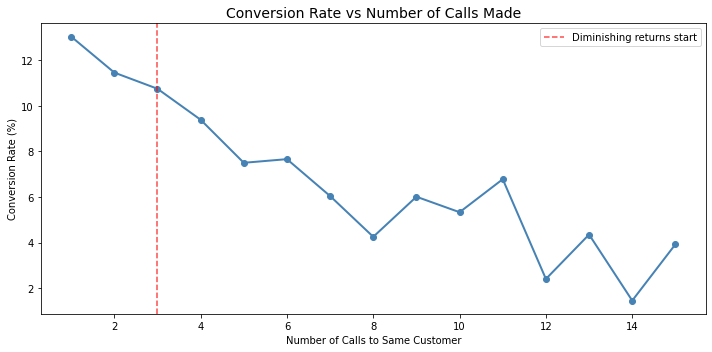

In [12]:
# ── KPI 3: Campaign efficiency — where are calls wasted? ────
# This is your operational bottleneck analysis

campaign_kpi = df.groupby('campaign').agg(
    contacts=('subscribed', 'count'),
    conversions=('subscribed', 'sum')
).reset_index()

campaign_kpi['conversion_rate'] = round(
    campaign_kpi['conversions'] / campaign_kpi['contacts'] * 100, 2
)

# Focus on first 15 calls — beyond this, diminishing returns kick in
campaign_kpi_filtered = campaign_kpi[campaign_kpi['campaign'] <= 15]

print("\nCampaign efficiency:\n", campaign_kpi_filtered)

# Chart 2: Line chart showing drop-off
plt.figure(figsize=(10, 5))
plt.plot(campaign_kpi_filtered['campaign'], campaign_kpi_filtered['conversion_rate'],
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Diminishing returns start')
plt.title('Conversion Rate vs Number of Calls Made', fontsize=14)
plt.xlabel('Number of Calls to Same Customer')
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/chart_02_campaign_efficiency.png', dpi=150)
plt.show()

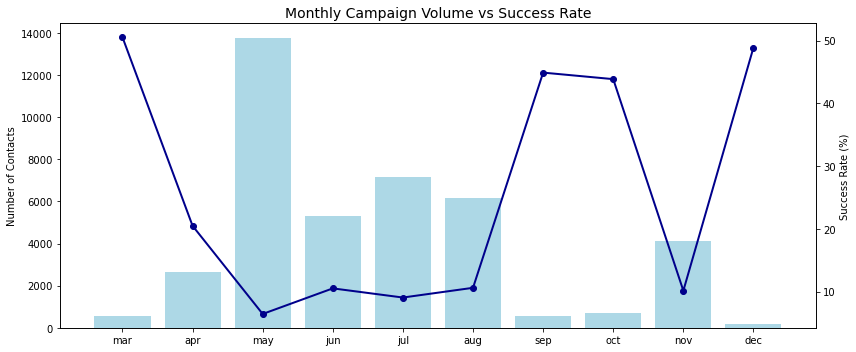

In [13]:
# ── KPI 4: Monthly performance ───────────────────────────────────────────────
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

monthly = df.groupby('month').agg(
    contacts=('subscribed', 'count'),
    subscriptions=('subscribed', 'sum')
).reset_index()

monthly['success_rate'] = round(monthly['subscriptions'] / monthly['contacts'] * 100, 2)
monthly['month'] = pd.Categorical(monthly['month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('month')

# Chart 3
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(monthly['month'], monthly['contacts'], color='lightblue', label='Contacts')
ax2.plot(monthly['month'], monthly['success_rate'], color='darkblue',
         marker='o', linewidth=2, label='Success Rate %')
ax1.set_ylabel('Number of Contacts')
ax2.set_ylabel('Success Rate (%)')
plt.title('Monthly Campaign Volume vs Success Rate', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/chart_03_monthly_performance.png', dpi=150)
plt.show()


Age band KPIs:
    age_band  total  subscribed  conversion_rate
0  Under 25   1068         256            23.97
1     25–34  13686        1666            12.17
2     35–44  13500        1168             8.65
3     45–54   8704         753             8.65
4     55–64   3567         484            13.57
5       65+    663         313            47.21


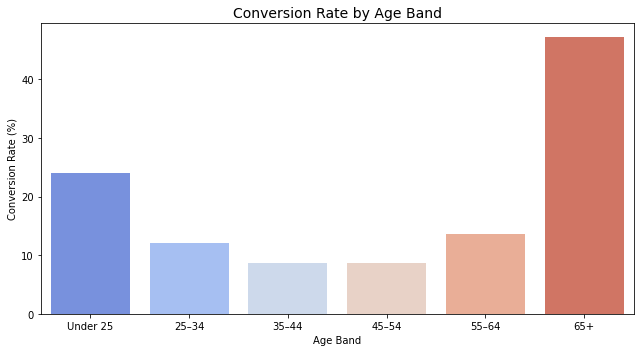

In [14]:
# ── KPI 5: Age band analysis ─────────────────────────────────────────────────
bins = [0, 24, 34, 44, 54, 64, 100]
labels = ['Under 25', '25–34', '35–44', '45–54', '55–64', '65+']
df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels)

age_kpi = df.groupby('age_band', observed=True).agg(
    total=('subscribed', 'count'),
    subscribed=('subscribed', 'sum')
).reset_index()

age_kpi['conversion_rate'] = round(age_kpi['subscribed'] / age_kpi['total'] * 100, 2)
print("\nAge band KPIs:\n", age_kpi)

# Chart 4
plt.figure(figsize=(9, 5))
sns.barplot(data=age_kpi, x='age_band', y='conversion_rate', palette='coolwarm')
plt.title('Conversion Rate by Age Band', fontsize=14)
plt.xlabel('Age Band')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.savefig('outputs/chart_04_age_band.png', dpi=150)
plt.show()